<a href="https://colab.research.google.com/github/manasamorthad/DeepLearning/blob/main/pretrainedmodels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#CNN

Number of classes: 24


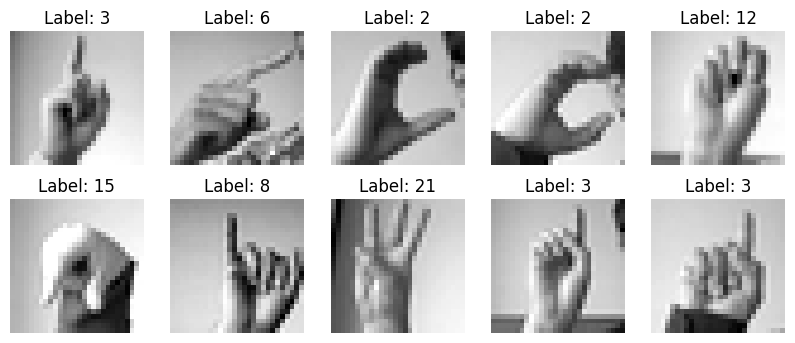

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,840 (886.09 KB)

 Trainable params: 226,840 (886.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.3458 - loss: 2.1822 - val_accuracy: 0.7626 - val_loss: 0.8725
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.7500 - loss: 0.7712 - val_accuracy: 0.9120 - val_loss: 0.3364
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.8688 - loss: 0.4056 - val_accuracy: 0.9720 - val_loss: 0.1468
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.9308 - loss: 0.2280 - val_accuracy: 0.9934 - val_loss: 0.0611
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.9567 - loss: 0.1458 - val_accuracy: 0.9980 - val_loss: 0.0260
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - accuracy: 0.9716 - loss: 0.0999 - val_accuracy: 0.9998 - val_loss: 0.0131
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.9798 - loss: 0.0739 - val_accuracy: 0.9995 - val_loss: 0.0118
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.9833 - loss: 0.0584 - 

In [ ]:
import pandas as pd
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import time

# Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# Separate labels and features
y_train = train.iloc[:, 0].values
X_train = train.iloc[:, 1:].values

y_test = test.iloc[:, 0].values
X_test = test.iloc[:, 1:].values

# Remap labels to continuous values
all_labels = sorted(np.unique(np.concatenate([y_train, y_test])))
label_map = {label: idx for idx, label in enumerate(all_labels)}

y_train = np.array([label_map[label] for label in y_train])
y_test = np.array([label_map[label] for label in y_test])

num_classes = len(all_labels)
print("Number of classes:", num_classes)

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Split into training and validation
X_train_main = X_train[:22000]
y_train_main = y_train[:22000]

X_val = X_train[22000:]
y_val = y_train[22000:]

# One-hot encoding
y_train_main = keras.utils.to_categorical(y_train_main, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_main[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train_main[i])}")
    plt.axis('off')
plt.show()

# Build Normal CNN Model
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary
model.summary()

# Training time
start_time = time.time()

history = model.fit(
    X_train_main,
    y_train_main,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val)
)

end_time = time.time()

print("Training Time: {:.2f} seconds".format(end_time - start_time))

# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

#LENET

Train labels: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Test labels: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Number of classes: 24


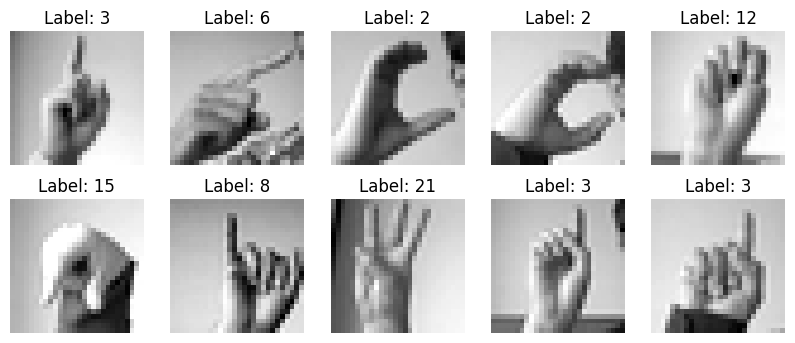

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 24)             │         2,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,616 (178.19 KB)

 Trainable params: 45,616 (178.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.3329 - loss: 2.2167 - val_accuracy: 0.5833 - val_loss: 1.3622
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.6648 - loss: 1.0481 - val_accuracy: 0.7604 - val_loss: 0.7645
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.8154 - loss: 0.5961 - val_accuracy: 0.8700 - val_loss: 0.4318
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.8977 - loss: 0.3352 - val_accuracy: 0.9135 - val_loss: 0.2836
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9440 - loss: 0.1967 - val_accuracy: 0.9681 - val_loss: 0.1261
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9763 - loss: 0.1035 - val_accuracy: 0.9791 - val_loss: 0.0918
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9883 - loss: 0.0626 - val_accuracy: 0.9804 - val_loss: 0.0654
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9931 - loss: 0.0407 - val_accu

In [ ]:
import pandas as pd
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import time


# Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# Separate labels and features
y_train = train.iloc[:, 0].values
X_train = train.iloc[:, 1:].values

y_test = test.iloc[:, 0].values
X_test = test.iloc[:, 1:].values

# Check unique labels
print("Train labels:", np.unique(y_train))
print("Test labels:", np.unique(y_test))

# Remap labels to continuous values: 0,1,2,3...
all_labels = sorted(np.unique(np.concatenate([y_train, y_test])))
label_map = {label: idx for idx, label in enumerate(all_labels)}

y_train = np.array([label_map[label] for label in y_train])
y_test = np.array([label_map[label] for label in y_test])

num_classes = len(all_labels)
print("Number of classes:", num_classes)

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape into 28x28x1
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Split training and validation
X_train_main = X_train[:22000]
y_train_main = y_train[:22000]

X_val = X_train[22000:]
y_val = y_train[22000:]

# One-hot encoding
y_train_main = keras.utils.to_categorical(y_train_main, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# Visualize some training images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_main[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train_main[i])}")
    plt.axis('off')
plt.show()

# Build LeNet-5 model
LeNet5_Model = Sequential()

LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1)))
LeNet5_Model.add(AveragePooling2D((2, 2)))

LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='relu'))
LeNet5_Model.add(AveragePooling2D((2, 2)))

LeNet5_Model.add(Flatten())

LeNet5_Model.add(Dense(120, activation='relu'))
model.add(Dropout(0.3))
LeNet5_Model.add(Dense(84, activation='relu'))
LeNet5_Model.add(Dense(num_classes, activation='softmax'))

# Compile model
LeNet5_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Summary
LeNet5_Model.summary()
start_time = time.time()
# Train model
history = LeNet5_Model.fit(
    X_train_main,
    y_train_main,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val)
)
end_time = time.time()
print("Training Time: {:.2f} seconds".format(end_time - start_time))
# Evaluate model
test_loss, test_acc = LeNet5_Model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


In [8]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential, Input
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

# Clear session
keras.backend.clear_session()

# Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# Separate labels and features
y_train = train.iloc[:, 0].values
X_train = train.iloc[:, 1:].values

y_test = test.iloc[:, 0].values
X_test = test.iloc[:, 1:].values

# Remap labels
all_labels = sorted(np.unique(np.concatenate([y_train, y_test])))
label_map = {label: idx for idx, label in enumerate(all_labels)}

y_train = np.array([label_map[label] for label in y_train])
y_test = np.array([label_map[label] for label in y_test])

num_classes = len(all_labels)
print("Number of classes:", num_classes)

# Normalize and reshape
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Split validation from training
X_train_main = X_train[:22000]
y_train_main = y_train[:22000]

X_val = X_train[22000:]
y_val = y_train[22000:]

# One-hot encode
y_train_main = keras.utils.to_categorical(y_train_main, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# Build smaller AlexNet-style model
model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),

    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train
start_time = time.time()

history = model.fit(
    X_train_main,
    y_train_main,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val)
)

end_time = time.time()
print("Training Time: {:.2f} seconds".format(end_time - start_time))

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)



Number of classes: 24


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,280,216 (8.70 MB)

 Trainable params: 2,278,808 (8.69 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.5865 - loss: 1.3966 - val_accuracy: 0.0401 - val_loss: 11.4058
Epoch 2/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9530 - loss: 0.1468 - val_accuracy: 0.8885 - val_loss: 0.3489
Epoch 3/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9817 - loss: 0.0597 - val_accuracy: 0.9765 - val_loss: 0.0662
Epoch 4/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9823 - loss: 0.0675 - val_accuracy: 0.8040 - val_loss: 1.3998
Epoch 5/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9870 - loss: 0.0560 - val_accuracy: 0.9808 - val_loss: 0.0463
Epoch 6/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9960 - loss: 0.0161 - val_accuracy: 1.0000 - val_loss: 1.6321e-04
Epoch 7/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9901 - loss: 0.0510 - val_accuracy: 0.9168 - val_loss: 0.3547
Epoch 8/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9877 - loss: 0.0567 - va

#ZFNET

In [9]:
model = Sequential()

model.add(keras.Input(shape=(28, 28, 1)))

model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary
model.summary()

# Train model
start_time = time.time()

history = model.fit(
    X_train_main,
    y_train_main,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val)
)

end_time = time.time()
print("Training Time: {:.2f} seconds".format(end_time - start_time))

# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541,592 (2.07 MB)

 Trainable params: 541,592 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.4870 - loss: 1.6384 - val_accuracy: 0.9560 - val_loss: 0.1860
Epoch 2/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9362 - loss: 0.1895 - val_accuracy: 0.9951 - val_loss: 0.0235
Epoch 3/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9784 - loss: 0.0671 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 4/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9900 - loss: 0.0326 - val_accuracy: 0.9998 - val_loss: 0.0025
Epoch 5/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9905 - loss: 0.0306 - val_accuracy: 0.9996 - val_loss: 0.0028
Epoch 6/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9905 - loss: 0.0281 - val_accuracy: 0.9989 - val_loss: 0.0031
Epoch 7/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9943 - loss: 0.0185 - val_accuracy: 0.9998 - val_loss: 0.0013
Epoch 8/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9933 - loss: 0.0189 - val_accuracy: 

#VGG NET

In [13]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import gc
import time

keras.backend.clear_session()

# Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# Separate labels and features
y_train = train.iloc[:, 0].values
x_train = train.iloc[:, 1:].values

y_test = test.iloc[:, 0].values
x_test = test.iloc[:, 1:].values

# Remap labels
all_labels = sorted(np.unique(np.concatenate([y_train, y_test])))
label_map = {label: idx for idx, label in enumerate(all_labels)}

y_train = np.array([label_map[label] for label in y_train])
y_test = np.array([label_map[label] for label in y_test])

num_classes = len(all_labels)
print("Number of classes:", num_classes)

# Normalize and reshape
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Train-validation split
x_train_main = x_train[:22000]
y_train_main = y_train[:22000]

x_val = x_train[22000:]
y_val = y_train[22000:]

# One-hot encoding
y_train_main = keras.utils.to_categorical(y_train_main, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# Build VGG-style model
model = Sequential()

model.add(keras.Input(shape=(28, 28, 1)))

model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

start_time = time.time()

history = model.fit(
    x_train_main, y_train_main,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val)
)

end_time = time.time()
print("Training Time: {:.2f} seconds".format(end_time - start_time))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)



Number of classes: 24


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,592 (2.36 MB)

 Trainable params: 617,592 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.0539 - loss: 3.1328 - val_accuracy: 0.3093 - val_loss: 2.1615
Epoch 2/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6633 - loss: 0.9880 - val_accuracy: 0.9676 - val_loss: 0.1052
Epoch 3/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9283 - loss: 0.2131 - val_accuracy: 0.9976 - val_loss: 0.0101
Epoch 4/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9747 - loss: 0.0802 - val_accuracy: 0.9998 - val_loss: 0.0015
Epoch 5/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9810 - loss: 0.0595 - val_accuracy: 1.0000 - val_loss: 6.2333e-04
Epoch 6/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9884 - loss: 0.0366 - val_accuracy: 0.9998 - val_loss: 4.0139e-04
Epoch 7/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9893 - loss: 0.0363 - val_accuracy: 0.9978 - val_loss: 0.0059
Epoch 8/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9917 - loss: 0.0308 - val_ac

#google net


In [14]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Conv2D, MaxPooling2D, AveragePooling2D, Dense, Dropout, Flatten, Concatenate
from keras.models import Model
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import gc
import time

keras.backend.clear_session()

# Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# Separate labels and features
y_train = train.iloc[:, 0].values
x_train = train.iloc[:, 1:].values

y_test = test.iloc[:, 0].values
x_test = test.iloc[:, 1:].values

# Remap labels
all_labels = sorted(np.unique(np.concatenate([y_train, y_test])))
label_map = {label: idx for idx, label in enumerate(all_labels)}

y_train = np.array([label_map[label] for label in y_train])
y_test = np.array([label_map[label] for label in y_test])

num_classes = len(all_labels)
print("Number of classes:", num_classes)

# Normalize and reshape
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Train-validation split
x_train_main = x_train[:22000]
y_train_main = y_train[:22000]

x_val = x_train[22000:]
y_val = y_train[22000:]

# One-hot encoding
y_train_main = keras.utils.to_categorical(y_train_main, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# Inception block
def inception_block(x, f1, f3r, f3, f5r, f5, pool_proj):
    path1 = Conv2D(f1, (1, 1), padding='same', activation='relu')(x)

    path2 = Conv2D(f3r, (1, 1), padding='same', activation='relu')(x)
    path2 = Conv2D(f3, (3, 3), padding='same', activation='relu')(path2)

    path3 = Conv2D(f5r, (1, 1), padding='same', activation='relu')(x)
    path3 = Conv2D(f5, (5, 5), padding='same', activation='relu')(path3)

    path4 = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    path4 = Conv2D(pool_proj, (1, 1), padding='same', activation='relu')(path4)

    return Concatenate()([path1, path2, path3, path4])

# Build GoogLeNet-style model
inputs = Input(shape=(28, 28, 1))

x = Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
x = MaxPooling2D((2, 2))(x)

x = inception_block(x, 32, 32, 48, 8, 16, 16)
x = inception_block(x, 64, 48, 64, 8, 16, 16)
x = MaxPooling2D((2, 2))(x)

x = inception_block(x, 64, 48, 64, 8, 16, 16)
x = AveragePooling2D((3, 3))(x)

x = Flatten()(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

start_time = time.time()

history = model.fit(
    x_train_main, y_train_main,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val)
)

end_time = time.time()
print("Training Time: {:.2f} seconds".format(end_time - start_time))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)



Number of classes: 24


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 14, 14,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │      2,080 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 14, 14, 8) │        520 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ max_pooling2d[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │      2,080 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │     13,872 │ conv2d_2[0][0]    │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │      3,216 │ conv2d_4[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 14, 14,    │      1,040 │ max_pooling2d_1[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14, 14,    │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │ 112)              │            │ conv2d_3[0][0],   │
│                     │                   │            │ conv2d_5[0][0],   │
│                     │                   │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 14, 14,    │      5,424 │ concatenate[0][0] │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 14, 14, 8) │        904 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 14, 14,    │      7,232 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │     27,712 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 14, 14,    │      3,216 │ conv2d_10[0][0] 

 Total params: 137,952 (538.88 KB)

 Trainable params: 137,952 (538.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step - accuracy: 0.2631 - loss: 2.4001 - val_accuracy: 0.7122 - val_loss: 0.8807
Epoch 2/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7974 - loss: 0.5971 - val_accuracy: 0.9622 - val_loss: 0.1622
Epoch 3/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9235 - loss: 0.2209 - val_accuracy: 0.9954 - val_loss: 0.0400
Epoch 4/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9604 - loss: 0.1170 - val_accuracy: 0.9987 - val_loss: 0.0180
Epoch 5/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9765 - loss: 0.0707 - val_accuracy: 0.9993 - val_loss: 0.0087
Epoch 6/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9846 - loss: 0.0489 - val_accuracy: 0.9984 - val_loss: 0.0083
Epoch 7/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9839 - loss: 0.0503 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 8/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9908 - loss: 0.0290 - val_acc

#resnet

In [15]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Conv2D, BatchNormalization, ReLU, Add, MaxPooling2D, GlobalAveragePooling2D, Dense
from keras.models import Model
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import gc
import time

keras.backend.clear_session()

# Load dataset
train = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/DL_datasets/sign_mnist_test.csv")

# Separate labels and features
y_train = train.iloc[:, 0].values
x_train = train.iloc[:, 1:].values

y_test = test.iloc[:, 0].values
x_test = test.iloc[:, 1:].values

# Remap labels
all_labels = sorted(np.unique(np.concatenate([y_train, y_test])))
label_map = {label: idx for idx, label in enumerate(all_labels)}

y_train = np.array([label_map[label] for label in y_train])
y_test = np.array([label_map[label] for label in y_test])

num_classes = len(all_labels)
print("Number of classes:", num_classes)

# Normalize and reshape
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Train-validation split
x_train_main = x_train[:22000]
y_train_main = y_train[:22000]

x_val = x_train[22000:]
y_val = y_train[22000:]

# One-hot encoding
y_train_main = keras.utils.to_categorical(y_train_main, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# Residual block
def residual_block(x, filters, stride=1):
    shortcut = x

    x = Conv2D(filters, (3, 3), strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

# Build ResNet-style model
inputs = Input(shape=(28, 28, 1))

x = Conv2D(32, (3, 3), padding='same')(inputs)
x = BatchNormalization()(x)
x = ReLU()(x)

x = residual_block(x, 32)
x = residual_block(x, 32)
x = MaxPooling2D((2, 2))(x)

x = residual_block(x, 64, stride=2)
x = residual_block(x, 64)

x = GlobalAveragePooling2D()(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

start_time = time.time()

history = model.fit(
    x_train_main, y_train_main,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val)
)

end_time = time.time()
print("Training Time: {:.2f} seconds".format(end_time - start_time))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)



Number of classes: 24


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │      9,248 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 28, 28,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │      9,248 │ re_lu_2[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │      9,248 │ re_lu_3[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 172,184 (672.59 KB)

 Trainable params: 171,224 (668.84 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.8400 - loss: 0.7092 - val_accuracy: 0.2031 - val_loss: 3.3693
Epoch 2/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 1.0000 - loss: 0.0158 - val_accuracy: 1.0000 - val_loss: 0.0144
Epoch 3/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9951 - loss: 0.0327 - val_accuracy: 0.7912 - val_loss: 0.6990
Epoch 4/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 5/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 7.2837e-04
Epoch 6/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 1.0000 - loss: 9.1667e-04 - val_accuracy: 1.0000 - val_loss: 4.2054e-04
Epoch 7/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 1.0000 - loss: 6.2703e-04 - val_accuracy: 1.0000 - val_loss: 3.0144e-04
Epoch 8/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - lo